# Compare Different Dynamic Trend models

In [2]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Union
from pathlib import Path
import glob
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add current working directory to Python path
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

print(f"Added to path: {current_dir}")

Added to path: c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\dynamic_trend_model


In [33]:
"""
Metrics Comparison Toolkit for Water Meter Anomaly Detection Models

This module provides utilities to load, analyze, and compare metrics
across multiple models in Jupyter notebooks with nice pandas table display.

Key Features:
- Load model results from CSV files
- Compute mean and standard deviation of metrics
- Add mean ± std for train / prediction time columns
- Display as formatted pandas DataFrame in Jupyter
- Filter by metric type (all vs non-zero only)

Purpose: Compare multiple anomaly detection models
"""

from pathlib import Path
from typing import List, Union
import glob

import numpy as np
import pandas as pd


# Extra columns for timing information
TIME_COLS = [
    "train_time_seconds",
    "second_train_time_seconds",
    "prediction_time_seconds",
]


def load_model_results(csv_filepath: str, verbose: bool = True) -> pd.DataFrame:
    """
    Load and filter model results from CSV file.

    Parameters
    ----------
    csv_filepath : str
        Path to CSV file with model results
    verbose : bool
        Print loading status

    Returns
    -------
    pd.DataFrame
        Dataframe with only successful runs
    """
    try:
        df = pd.read_csv(csv_filepath)
        successful = df[df['status'] == 'success'].copy()

        if verbose and len(successful) > 0:
            print(f"✓ Loaded {len(successful)} successful runs")

        return successful
    except Exception as e:
        print(f"✗ Error loading {csv_filepath}: {e}")
        return pd.DataFrame()


def extract_metrics(df: pd.DataFrame, include_non_zero_only: bool = False) -> pd.DataFrame:
    """
    Extract metric columns from results dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Results dataframe
    include_non_zero_only : bool
        If True, extract only _nz metrics

    Returns
    -------
    pd.DataFrame
        Dataframe with only metric columns
    """
    metric_cols = [col for col in df.columns if col.startswith('metric_')]

    if include_non_zero_only:
        # Include only non-zero and summary metrics
        metric_cols = [
            col for col in metric_cols
            if col.endswith('_nz') or
               col in [
                   'metric_total_count',
                   'metric_non_zero_count',
                   'metric_zero_count',
                   'metric_non_zero_percentage',
               ]
        ]

    return df[metric_cols]


def compute_metrics_summary(csv_filepaths: List[str],
                            model_names: List[str] = None,
                            include_non_zero_only: bool = False,
                            only_converged: bool = False,
                            verbose: bool = True) -> pd.DataFrame:
    """
    Compute mean and std of metrics across samples for each model.

    Creates a summary table where:
    - Rows: Different metrics (metric_* + time columns)
    - Columns: Model names with Mean and Std subcolumns

    Parameters
    ----------
    csv_filepaths : List[str]
        List of CSV file paths
    model_names : List[str], optional
        Names for each model. If None, uses filenames.
    include_non_zero_only : bool
        If True, only include non-zero metrics
    only_converged : bool
        If True, compute metrics only on rows where converged == True
    verbose : bool
        Print loading progress

    Returns
    -------
    pd.DataFrame
        Summary table with metrics as rows and models as columns
    """

    if not csv_filepaths:
        raise ValueError("No CSV files found")

    # Set default model names
    if model_names is None:
        model_names = [Path(f).stem for f in csv_filepaths]

    if len(csv_filepaths) != len(model_names):
        raise ValueError(f"Mismatch: {len(csv_filepaths)} files vs {len(model_names)} names")

    # Load data
    model_data_metrics = {}
    model_data_full = {}
    all_metrics = set()
    successful_counts = {}

    if verbose:
        print(f"Loading {len(csv_filepaths)} model(s)...")
        print("-" * 80)

    for filepath, model_name in zip(csv_filepaths, model_names):
        df = load_model_results(filepath, verbose=verbose)

        # Filter only converged problems (if requested and column exists)
        if only_converged and 'converged_train' in df.columns:
            df = df[(df['converged_train'] == True) &
                    (df['converged_second'] == True)].copy()
            if verbose:
                print(f"  {model_name}: filtered to {len(df)} converged_train runs")

        if len(df) > 0:
            metrics_df = extract_metrics(df, include_non_zero_only)
            model_data_metrics[model_name] = metrics_df
            model_data_full[model_name] = df
            successful_counts[model_name] = len(metrics_df)
            all_metrics.update(metrics_df.columns)
        else:
            model_data_metrics[model_name] = None
            model_data_full[model_name] = None
            successful_counts[model_name] = 0

    if verbose:
        print("-" * 80)

    # Build summary table rows for metric_* columns
    all_metrics = sorted(all_metrics)
    summary_rows = []

    for metric in all_metrics:
        row_data = {'Metric': metric}

        for model_name in model_names:
            if model_data_metrics[model_name] is None:
                row_data[f"{model_name}_Mean"] = np.nan
                row_data[f"{model_name}_Std"] = np.nan
            else:
                metrics_df = model_data_metrics[model_name]
                if metric in metrics_df.columns:
                    row_data[f"{model_name}_Mean"] = metrics_df[metric].mean()
                    row_data[f"{model_name}_Std"] = metrics_df[metric].std()
                else:
                    row_data[f"{model_name}_Mean"] = np.nan
                    row_data[f"{model_name}_Std"] = np.nan

        summary_rows.append(row_data)

    # Add rows for timing columns
    for time_col in TIME_COLS:
        row_data = {'Metric': time_col}

        for model_name in model_names:
            df_full = model_data_full.get(model_name)
            if df_full is None or time_col not in df_full.columns:
                row_data[f"{model_name}_Mean"] = np.nan
                row_data[f"{model_name}_Std"] = np.nan
            else:
                row_data[f"{model_name}_Mean"] = df_full[time_col].mean()
                row_data[f"{model_name}_Std"] = df_full[time_col].std()

        summary_rows.append(row_data)

    summary_df = pd.DataFrame(summary_rows)

    # Store metadata
    summary_df.attrs['model_names'] = model_names
    summary_df.attrs['successful_counts'] = successful_counts
    summary_df.attrs['include_non_zero_only'] = include_non_zero_only
    summary_df.attrs['only_converged'] = only_converged

    return summary_df


def format_metrics_table(summary_df: pd.DataFrame,
                         model_names: List[str] = None,
                         decimal_places: int = 4,
                         include_non_zero_only: bool = False) -> pd.DataFrame:
    """
    Format metrics summary table as "mean ± std" for display.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    model_names : List[str], optional
        Model names (auto-detected if not provided)
    decimal_places : int
        Decimal places for values
    include_non_zero_only : bool
        Show only non-zero metrics (time rows are always kept)

    Returns
    -------
    pd.DataFrame
        Formatted table with "mean ± std" values ready for display
    """

    if model_names is None:
        model_names = summary_df.attrs.get(
            'model_names',
            list(set([
                col.replace('_Mean', '').replace('_Std', '')
                for col in summary_df.columns if col != 'Metric'
            ]))
        )

    # Filter rows
    df_display = summary_df.copy()
    if include_non_zero_only:
        df_display = df_display[
            df_display['Metric'].str.contains(
                '_nz|total_count|non_zero_count|non_zero_percentage', na=False
            )
            | df_display['Metric'].isin(TIME_COLS)
        ].copy()

    # Format as "mean ± std"
    formatted_rows = []

    for _, row in df_display.iterrows():
        formatted_row = {'Metric': row['Metric']}

        for model_name in model_names:
            mean_col = f"{model_name}_Mean"
            std_col = f"{model_name}_Std"

            mean_val = row.get(mean_col, np.nan)
            std_val = row.get(std_col, np.nan)

            if pd.notna(mean_val) and pd.notna(std_val):
                formatted_row[model_name] = f"{mean_val:.{decimal_places}f} ± {std_val:.{decimal_places}f}"
            else:
                formatted_row[model_name] = "N/A"

        formatted_rows.append(formatted_row)

    return pd.DataFrame(formatted_rows)


def display_metrics(summary_df: pd.DataFrame,
                    model_names: List[str] = None,
                    show_all: bool = False,
                    decimal_places: int = 4) -> pd.DataFrame:
    """
    Display metrics summary as a nice pandas table in Jupyter.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    model_names : List[str], optional
        Model names
    show_all : bool
        If False, show only non-zero metrics (recommended)
    decimal_places : int
        Number of decimal places

    Returns
    -------
    pd.DataFrame
        Formatted table for display

    Examples
    --------
    >>> summary = compute_metrics_summary(csv_files, ['LSTM', 'GRU'])
    >>> table = display_metrics(summary, show_all=False)
    >>> display(table)  # In Jupyter
    """

    if model_names is None:
        model_names = summary_df.attrs.get(
            'model_names',
            list(set([
                col.replace('_Mean', '').replace('_Std', '')
                for col in summary_df.columns if col != 'Metric'
            ]))
        )

    # Format table
    formatted = format_metrics_table(
        summary_df,
        model_names,
        decimal_places,
        include_non_zero_only=not show_all,
    )

    # Print summary info
    print(f"Metrics Summary - {'Non-Zero Metrics' if not show_all else 'All Metrics'}")
    print(f"Models: {', '.join(model_names)}")

    if hasattr(summary_df, 'attrs') and 'successful_counts' in summary_df.attrs:
        counts = summary_df.attrs['successful_counts']
        for m in model_names:
            print(f"  {m}: {counts[m]} successful runs")

    print()

    # Configure pandas display
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)

    return formatted


def get_metric_comparison(summary_df: pd.DataFrame,
                          metric_name: str,
                          model_names: List[str] = None) -> pd.DataFrame:
    """
    Extract comparison for a specific metric across models.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    metric_name : str
        Name of metric to compare
    model_names : List[str], optional
        Model names

    Returns
    -------
    pd.DataFrame
        Comparison table for metric

    Examples
    --------
    >>> mae_nz = get_metric_comparison(summary, 'metric_mae_nz')
    >>> display(mae_nz)
    """

    if model_names is None:
        model_names = summary_df.attrs.get(
            'model_names',
            list(set([
                col.replace('_Mean', '').replace('_Std', '')
                for col in summary_df.columns if col != 'Metric'
            ]))
        )

    metric_row = summary_df[summary_df['Metric'] == metric_name]

    if len(metric_row) == 0:
        print(f"✗ Metric '{metric_name}' not found")
        print("\nAvailable metrics:")
        for i, m in enumerate(sorted(summary_df['Metric'].unique()), 1):
            print(f"  {i:2}. {m}")
        return None

    comparison = [{'Metric': metric_name}]

    for model_name in model_names:
        mean_val = metric_row[f"{model_name}_Mean"].values[0]
        std_val = metric_row[f"{model_name}_Std"].values[0]

        if pd.notna(mean_val):
            comparison[0][model_name] = f"{mean_val:.6f} ± {std_val:.6f}"
        else:
            comparison[0][model_name] = "N/A"

    return pd.DataFrame(comparison)


def list_available_metrics(summary_df: pd.DataFrame) -> None:
    """
    Display list of available metrics.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    """
    metrics = sorted(summary_df['Metric'].unique())

    print(f"Available metrics ({len(metrics)} total):\n")

    for i, m in enumerate(metrics, 1):
        print(f"  {i:2}. {m}")


# ============================================================================
# EXAMPLE USAGE IN JUPYTER NOTEBOOK
# ============================================================================
"""
Example Usage:
==============

# 1. Load results from multiple models
csv_files = ['lstm_results.csv', 'gru_results.csv', 'transformer_results.csv']
model_names = ['LSTM', 'GRU', 'Transformer']

# 2. Compute summary statistics
summary = compute_metrics_summary(csv_files, model_names)

# 3. Display as formatted pandas table (non-zero metrics + time columns)
table = display_metrics(summary, show_all=False)
display(table)  # Use IPython display in Jupyter

# 4. Display all metrics
table_all = display_metrics(summary, show_all=True)
display(table_all)

# 5. Compare specific metric or time column
mae_comparison = get_metric_comparison(summary, 'metric_mae_nz')
display(mae_comparison)

train_time_cmp = get_metric_comparison(summary, 'train_time_seconds')
display(train_time_cmp)

# 6. List available metrics
list_available_metrics(summary)
"""


"\nExample Usage:\n==============\n\n# 1. Load results from multiple models\ncsv_files = ['lstm_results.csv', 'gru_results.csv', 'transformer_results.csv']\nmodel_names = ['LSTM', 'GRU', 'Transformer']\n\n# 2. Compute summary statistics\nsummary = compute_metrics_summary(csv_files, model_names)\n\n# 3. Display as formatted pandas table (non-zero metrics + time columns)\ntable = display_metrics(summary, show_all=False)\ndisplay(table)  # Use IPython display in Jupyter\n\n# 4. Display all metrics\ntable_all = display_metrics(summary, show_all=True)\ndisplay(table_all)\n\n# 5. Compare specific metric or time column\nmae_comparison = get_metric_comparison(summary, 'metric_mae_nz')\ndisplay(mae_comparison)\n\ntrain_time_cmp = get_metric_comparison(summary, 'train_time_seconds')\ndisplay(train_time_cmp)\n\n# 6. List available metrics\nlist_available_metrics(summary)\n"

In [5]:
csv_files = ['results_local_trend_1000_seed_42_fixed_params_clipped.csv', 'results_seasonal_uc_1000_seed_42_daily_clipped.csv', ]
model_names = ['Local Linear Trend', 'Seasonal Local Linear Trend']

# 2. Compute summary statistics
summary = compute_metrics_summary(csv_files, model_names=model_names)
table = display_metrics(summary, show_all=True)
display(table)  # Use IPython display in Jupyter

Loading 2 model(s)...
--------------------------------------------------------------------------------
✓ Loaded 830 successful runs
✓ Loaded 827 successful runs
--------------------------------------------------------------------------------
Metrics Summary - All Metrics
Models: Local Linear Trend, Seasonal Local Linear Trend
  Local Linear Trend: 830 successful runs
  Seasonal Local Linear Trend: 827 successful runs



,Metric,Local Linear Trend,Seasonal Local Linear Trend
0,metric_direction_accuracy,0.5885 ± 0.2060,0.6115 ± 0.1336
1,metric_direction_accuracy_nz,0.4243 ± 0.0974,0.5368 ± 0.1022
2,metric_mae,0.1058 ± 0.5032,1.8586 ± 50.3562
3,metric_mae_nz,0.1333 ± 0.5539,0.1324 ± 0.5948
4,metric_mape,18171641561805.7031 ± 127082505592809.9688,7904448311050184.0000 ± 226787030045906720.0000
5,metric_mape_nz,1.1029 ± 1.0684,1.1599 ± 1.3359
6,metric_max_residual,0.9262 ± 4.7238,257.5187 ± 7379.2405
7,metric_max_residual_nz,0.9930 ± 4.8913,0.9849 ± 4.7063
8,metric_mean_residual,0.1058 ± 0.5032,1.8586 ± 50.3562
9,metric_mean_residual_nz,0.1333 ± 0.5539,0.1324 ± 0.5948


In [6]:
# 2. Compute summary statistics
summary_converged_only = compute_metrics_summary(csv_files, only_converged=True, model_names=model_names)
table = display_metrics(summary_converged_only, show_all=True)
display(table)  # Use IPython display in Jupyter

Loading 2 model(s)...
--------------------------------------------------------------------------------
✓ Loaded 830 successful runs
  Local Linear Trend: filtered to 666 converged_train runs
✓ Loaded 827 successful runs
  Seasonal Local Linear Trend: filtered to 604 converged_train runs
--------------------------------------------------------------------------------
Metrics Summary - All Metrics
Models: Local Linear Trend, Seasonal Local Linear Trend
  Local Linear Trend: 666 successful runs
  Seasonal Local Linear Trend: 604 successful runs



,Metric,Local Linear Trend,Seasonal Local Linear Trend
0,metric_direction_accuracy,0.5384 ± 0.1685,0.5838 ± 0.0965
1,metric_direction_accuracy_nz,0.4292 ± 0.0914,0.5439 ± 0.0953
2,metric_mae,0.1294 ± 0.5591,0.1416 ± 0.6376
3,metric_mae_nz,0.1457 ± 0.5922,0.1598 ± 0.6697
4,metric_mape,19766172544609.5781 ± 139961063036991.5000,21823465731707.4062 ± 171407121543925.9062
5,metric_mape_nz,1.1214 ± 1.1359,1.1882 ± 1.4759
6,metric_max_residual,1.0504 ± 4.9881,1.1971 ± 5.2785
7,metric_max_residual_nz,1.0593 ± 5.0098,1.2136 ± 5.3204
8,metric_mean_residual,0.1294 ± 0.5591,0.1416 ± 0.6376
9,metric_mean_residual_nz,0.1457 ± 0.5922,0.1598 ± 0.6697


In [7]:
def _prepare_time_filtered_df(df, start_date=None, end_date=None):
    """Helper: ensure datetime and filter by dates."""
    df = df.copy()

    if not pd.api.types.is_datetime64_any_dtype(df["timestamp_utc"]):
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])

    if start_date is not None or end_date is not None:
        if isinstance(start_date, str):
            start_date = pd.to_datetime(start_date)
        if isinstance(end_date, str):
            end_date = pd.to_datetime(end_date)

        if start_date is not None:
            df = df[df["timestamp_utc"] >= start_date]
        if end_date is not None:
            df = df[df["timestamp_utc"] <= end_date]

    return df


def plot_water_meter_anomalies(
    df_actuals,
    df_predicted,
    df_red_dots,
    figsize=(14, 6),
    title="Water Meter: Actual vs Predicted Values",
    start_date=None,
    end_date=None,
):
    """
    df_actuals:  columns timestamp_utc, Diff, (optional) is_anomaly
    df_predicted: columns timestamp_utc, predicted, (optional) anomaly_score, is_anomaly
    df_red_dots: columns timestamp_utc (candidate extra timestamps)
    """

    # Prepare and filter separately
    df_a = _prepare_time_filtered_df(df_actuals, start_date, end_date)
    df_p = _prepare_time_filtered_df(df_predicted, start_date, end_date)
    df_r = _prepare_time_filtered_df(df_red_dots, start_date, end_date)

    # Keep only timestamps where Diff is NaN in df_a but not NaN in df_r
    if not df_a.empty and not df_r.empty:
        # Select only needed columns to avoid clashes
        tmp_a = df_a[["timestamp_utc", "Diff"]].rename(columns={"Diff": "Diff_a"})
        tmp_r = df_r[["timestamp_utc", "Diff"]].rename(columns={"Diff": "Diff_r"})
    
        merged = tmp_r.merge(tmp_a, on="timestamp_utc", how="left")
    
        # Condition: Diff_a is NaN (missing in actuals) AND Diff_r is not NaN
        mask = merged["Diff_a"].isna() & merged["Diff_r"].notna()
    
        # Keep only those timestamps in df_r
        df_r = df_r[df_r["timestamp_utc"].isin(merged.loc[mask, "timestamp_utc"])]


    # Update title if zoomed
    if start_date is not None and end_date is not None:
        if isinstance(start_date, str):
            start_date = pd.to_datetime(start_date)
        if isinstance(end_date, str):
            end_date = pd.to_datetime(end_date)
        date_range = (
            f" ({start_date.strftime('%Y-%m-%d %H:%M')} "
            f"to {end_date.strftime('%Y-%m-%d %H:%M')})"
        )
        title = title + date_range

    fig, ax = plt.subplots(figsize=figsize, dpi=100)

    # Actuals (Diff)
    ax.plot(
        df_a["timestamp_utc"],
        df_a["Diff"],
        color="#2E86AB",
        linewidth=2.5,
        marker="o",
        markersize=5,
        label="Actual (Diff)",
        zorder=3,
        alpha=0.9,
    )

    # Predicted
    ax.plot(
        df_p["timestamp_utc"],
        df_p["predicted"],
        color="#A23B72",
        linewidth=2,
        marker="s",
        markersize=4,
        label="Predicted",
        zorder=2,
        alpha=0.8,
        linestyle="--",
    )

    # Red dots only for timestamps not in df_actuals
    if not df_r.empty:
        ax.scatter(
            df_r["timestamp_utc"],
            df_r["Diff"],  # or np.nan if you want them detached from y-scale
            color="red",
            s=40,
            marker="o",
            label="Extra timestamps",
            zorder=5,
        )

    # Optional anomalies on actuals
    if "is_anomaly" in df_a.columns:
        anomalies = df_a[df_a["is_anomaly"] == 1]
        if len(anomalies) > 0:
            ax.scatter(
                anomalies["timestamp_utc"],
                anomalies["Diff"],
                color="#F18F01",
                s=150,
                marker="X",
                label="Anomaly (Actual)",
                zorder=4,
                edgecolors="#C41E3A",
                linewidth=2,
            )

    ax.set_xlabel("Timestamp (UTC)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Water Consumption (Diff)", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=20)

    # Determine global time range from all non-empty dfs
    timestamps = []
    for d in (df_a, df_p, df_r):
        if not d.empty:
            timestamps.append(d["timestamp_utc"].min())
            timestamps.append(d["timestamp_utc"].max())

    if timestamps:
        t_min, t_max = min(timestamps), max(timestamps)
        time_range = (t_max - t_min).total_seconds()
    else:
        time_range = 0

    if time_range < 3600:
        date_format = "%H:%M:%S"
        date_locator = mdates.MinuteLocator(interval=10)
    elif time_range < 86400:
        date_format = "%H:%M"
        date_locator = mdates.HourLocator(interval=2)
    elif time_range < 604800:
        date_format = "%Y-%m-%d %H:%M"
        date_locator = mdates.AutoDateLocator()
    else:
        date_format = "%Y-%m-%d"
        date_locator = mdates.AutoDateLocator()

    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    ax.xaxis.set_major_locator(date_locator)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.7)
    ax.set_axisbelow(True)
    ax.legend(loc="best", fontsize=10, framealpha=0.95)
    ax.set_facecolor("#F8F9FA")
    fig.patch.set_facecolor("white")
    fig.tight_layout()

    return fig, ax


def plot_residuals_and_anomalies(
    df_actuals,
    df_predicted,
    figsize=(14, 8),
    start_date=None,
    end_date=None,
):
    """
    Residuals computed at actual timestamps by interpolating predicted series.
    """

    df_a = _prepare_time_filtered_df(df_actuals, start_date, end_date)
    df_p = _prepare_time_filtered_df(df_predicted, start_date, end_date)

    # Build a predicted series aligned to actual timestamps (time-based interpolation)
    # Set index for convenient reindex + interpolate
    p = df_p.set_index("timestamp_utc")["predicted"].sort_index()
    a = df_a.set_index("timestamp_utc")["Diff"].sort_index()

    # Reindex predicted to actual timestamps and interpolate in time
    p_on_a = p.reindex(a.index.union(p.index)).sort_index().interpolate(method="time")
    p_on_a = p_on_a.reindex(a.index)

    df_res = pd.DataFrame({
        "timestamp_utc": a.index,
        "actual": a.values,
        "predicted": p_on_a.values,
    })
    df_res["residual"] = df_res["actual"] - df_res["predicted"]

    if "is_anomaly" in df_a.columns:
        df_res["is_anomaly"] = df_a.set_index("timestamp_utc")["is_anomaly"].reindex(df_res["timestamp_utc"]).fillna(0).astype(int)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, dpi=100)

    # Panel 1: Residuals
    if "is_anomaly" in df_res.columns:
        colors = ["#C41E3A" if x == 1 else "#2E86AB" for x in df_res["is_anomaly"]]
    else:
        colors = "#2E86AB"

    ax1.bar(
        df_res["timestamp_utc"],
        df_res["residual"],
        color=colors,
        alpha=0.7,
        width=0.01,
    )
    ax1.axhline(y=0, color="black", linestyle="-", linewidth=0.8, alpha=0.5)
    ax1.set_ylabel("Residual (Actual - Predicted)", fontsize=11, fontweight="bold")
    ax1.set_title("Prediction Residuals with Anomalies Highlighted", fontsize=12, fontweight="bold")
    ax1.grid(True, alpha=0.3, axis="y")
    ax1.set_facecolor("#F8F9FA")

    # Panel 2: Anomaly scores from df_predicted (if you have them)
    if "anomaly_score" in df_predicted.columns and df_predicted["anomaly_score"].notna().any():
        ax2.plot(
            df_predicted["timestamp_utc"],
            df_predicted["anomaly_score"],
            color="#F18F01",
            linewidth=2,
            marker="o",
            markersize=5,
            label="Anomaly Score",
        )

        if "is_anomaly" in df_predicted.columns:
            anomalies_p = df_predicted[df_predicted["is_anomaly"] == 1]
            if len(anomalies_p) > 0:
                ax2.scatter(
                    anomalies_p["timestamp_utc"],
                    anomalies_p["anomaly_score"],
                    color="#C41E3A",
                    s=150,
                    marker="X",
                    label="Detected Anomaly",
                    zorder=4,
                )

        ax2.set_ylabel("Anomaly Score", fontsize=11, fontweight="bold")
        ax2.legend(loc="best", fontsize=10)
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(
            0.5,
            0.5,
            "No anomaly scores available",
            ha="center",
            va="center",
            transform=ax2.transAxes,
            fontsize=12,
        )

    # Adaptive date formatting using union of both ranges
    t_min = min(df_a["timestamp_utc"].min(), df_p["timestamp_utc"].min())
    t_max = max(df_a["timestamp_utc"].max(), df_p["timestamp_utc"].max())
    time_range = (t_max - t_min).total_seconds()

    if time_range < 3600:
        date_format = "%H:%M:%S"
        date_locator = mdates.MinuteLocator(interval=10)
    elif time_range < 86400:
        date_format = "%H:%M"
        date_locator = mdates.HourLocator(interval=2)
    elif time_range < 604800:
        date_format = "%Y-%m-%d %H:%M"
        date_locator = mdates.AutoDateLocator()
    else:
        date_format = "%Y-%m-%d"
        date_locator = mdates.AutoDateLocator()

    ax2.set_xlabel("Timestamp (UTC)", fontsize=11, fontweight="bold")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    ax2.xaxis.set_major_locator(date_locator)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha="right")
    ax2.set_facecolor("#F8F9FA")

    fig.tight_layout()
    return fig, (ax1, ax2)



In [8]:
import pandas as pd
import numpy as np
import operator

def get_candidates(df, params):
    ops = {
        "==": operator.eq,
        "!=": operator.ne,
        "<": operator.lt,
        ">": operator.gt,
        "<=": operator.le,
        ">=": operator.ge,
    }

    mask = np.ones(len(df), dtype=bool)
    
    for p in params:
        col = p["name"]
        val = p["value"]
        comp = p["comparator"]
        
        if comp not in ops:
            raise ValueError(f"Unsupported comparator: {comp}")
        if col not in df.columns:
            raise ValueError(f"Column {col} not in dataframe")
        
        op = ops[comp]
        mask &= op(df[col], val)
        
    return df[mask]

def pick_random_file(df_seasonal, df_local, params=None, seed=42):
    """
    params: list of dicts, e.g.
        [
            {"name": "window_size", "value": 12, "comparator": ">="},
            {"name": "status", "value": "success", "comparator": "=="},
        ]
    seed: integer or None, forwarded to pandas.sample(random_state=seed)
    """
    if params is None or len(params) == 0:
        candidates = df_seasonal.copy()
    else:
        candidates =get_candidates(df_seasonal, params=params)

    if candidates.empty:
        raise ValueError("No rows match the given condition(s).")

    row = candidates.sample(1, random_state=seed).iloc[0]
    #print(row)
    
    filename = row["filename"]
    
    row_local = df_local[df_local['filename'] == filename].squeeze()
    #print(row_local)
    
    # union of all columns
    all_cols = row.index.union(row_local.index)
    
    cmp = pd.DataFrame(
        [
            row.reindex(all_cols),
            row_local.reindex(all_cols),
        ],
        index=["seasonal", "local_linear"],
    )

    display(cmp.T)
        
    return filename



In [9]:
df_metrics_seasonal = pd.read_csv('./results_seasonal_uc_1000_seed_42_daily_clipped.csv')
df_metrics_local = pd.read_csv('./results_local_trend_1000_seed_42_fixed_params_clipped.csv')

filename = pick_random_file(
    df_metrics_seasonal,
    df_metrics_local,
    params=[
        {"name": "converged_train", "value": True, "comparator": "=="},
        {"name": "converged_second", "value": True, "comparator": "=="},
        {"name": "status", "value": "success", "comparator": "=="},
        #{"name": "metric_mape_nz", "value": 0.1, "comparator": ">"},
    ],
    seed=42,
)

meter_id = 131493
#137402 - normal one, big acf1 on non seasonal
#90986 - convergede but spikes
#131493 - big acf1 even seasonal
#106555 - stoupajici diff
#58425 - unconverged train but second yes - long seasonal train time, 10min period, small gopt
#108627 - converged local, unconverged seasonal, not enough data
#144433 - same as above just enogh data but random spikes
#141674 - both unconverged - flat
#131721 - both unconverged - not flat, small gopt

,seasonal,local_linear
anomalies_detected,0.0,0.0
converged_second,True,True
converged_train,True,True
error,NaN,NaN
filename,124459,124459
filepath,../data_w_diff_001\124459.csv,../data_w_diff_001\124459.csv
gopt_second,NaN,NaN
gopt_train,NaN,NaN
metric_direction_accuracy,0.730769,0.153846
metric_direction_accuracy_nz,0.730769,0.153846


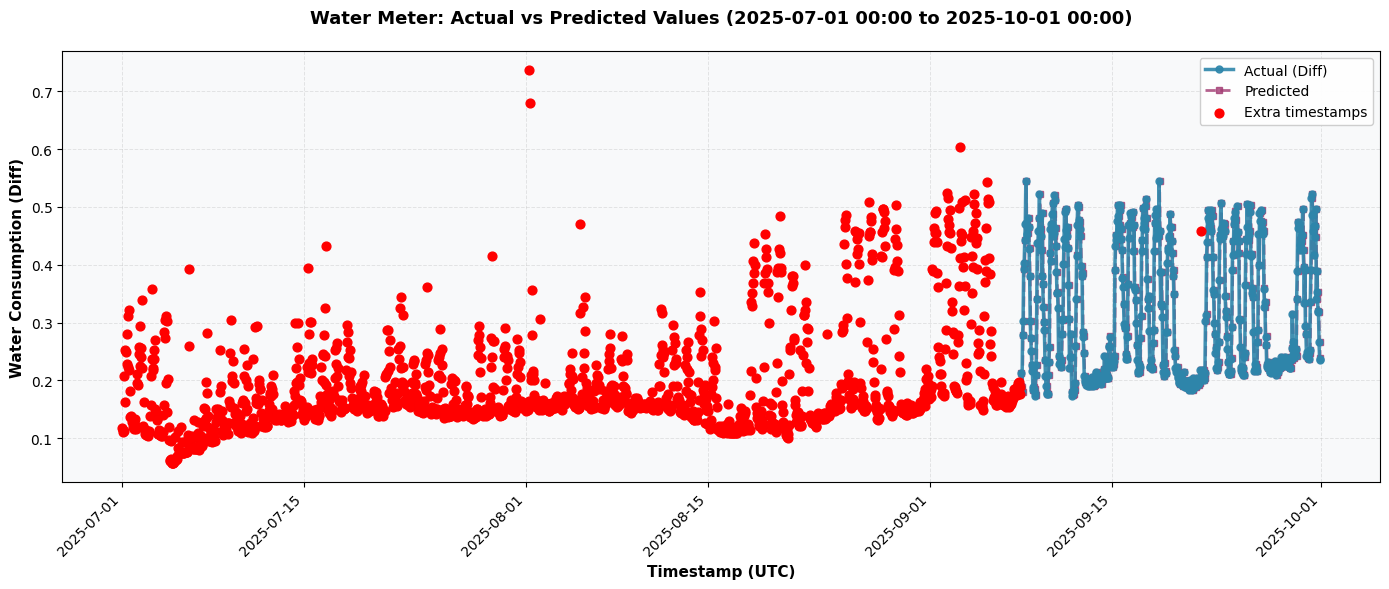

In [10]:
from local_level_fixed_slope import process_single_meter
process_single_meter(f'../data_w_diff_001/{meter_id}.csv', predictions_output_csv='../test_pred.csv')
df_predicted = pd.read_csv('../test_pred.csv')
df_predicted['timestamp_utc'] = pd.to_datetime(df_predicted['timestamp_utc'])

df_actuals_dots = pd.read_csv(f'../data_w_diff_001/{meter_id}.csv').dropna()
df_actuals_dots['timestamp_utc'] = pd.to_datetime(df_actuals_dots['timestamp_utc'])

df_actuals_with_gaps = df_predicted[['actual', 'timestamp_utc']].rename(columns={'actual': 'Diff'})

fig1, ax1 = plot_water_meter_anomalies(df_actuals=df_actuals_with_gaps, df_predicted=df_predicted, df_red_dots=df_actuals_dots,
    start_date='2025-07-01 00:00:00+00:00',
    end_date='2025-10-01 00:00:00+00:00')
plt.show()

In [11]:
start_date = '2025-09-10 00:00:00+00:00'
end_date = '2025-09-15 00:00:00+00:00'

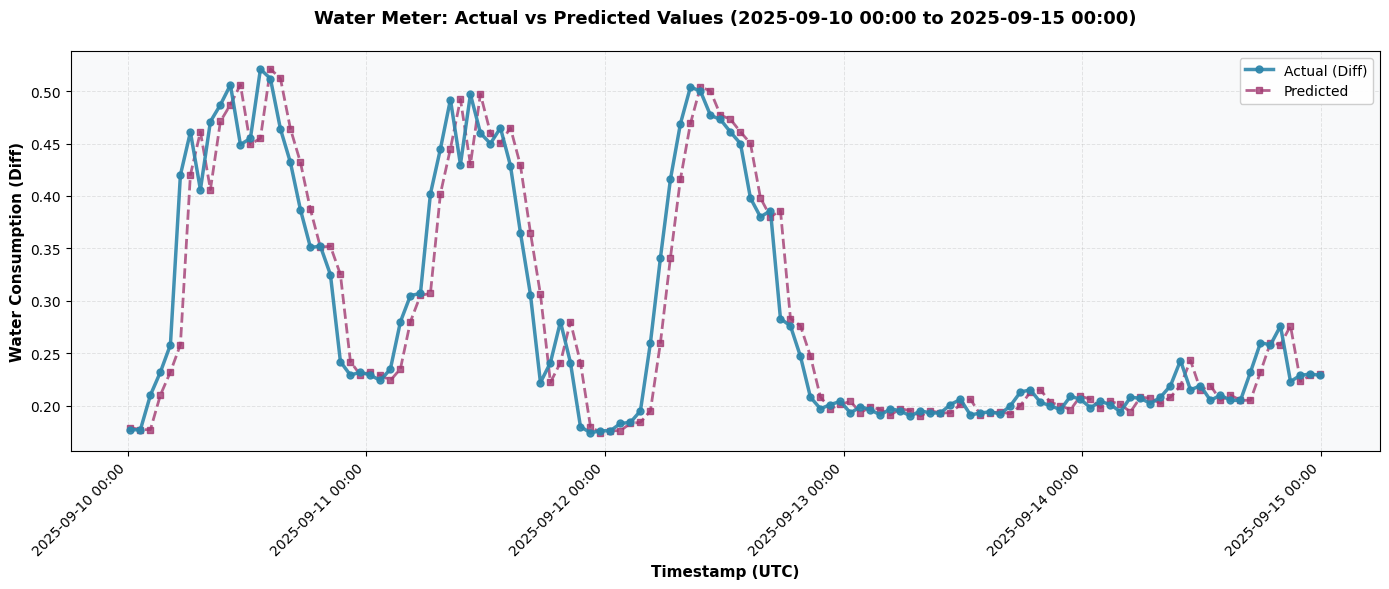

In [12]:
fig2, ax2 = plot_water_meter_anomalies(df_actuals=df_actuals_with_gaps, df_predicted=df_predicted, df_red_dots=df_actuals_dots, 
        start_date=start_date,
        end_date=end_date)
plt.show()

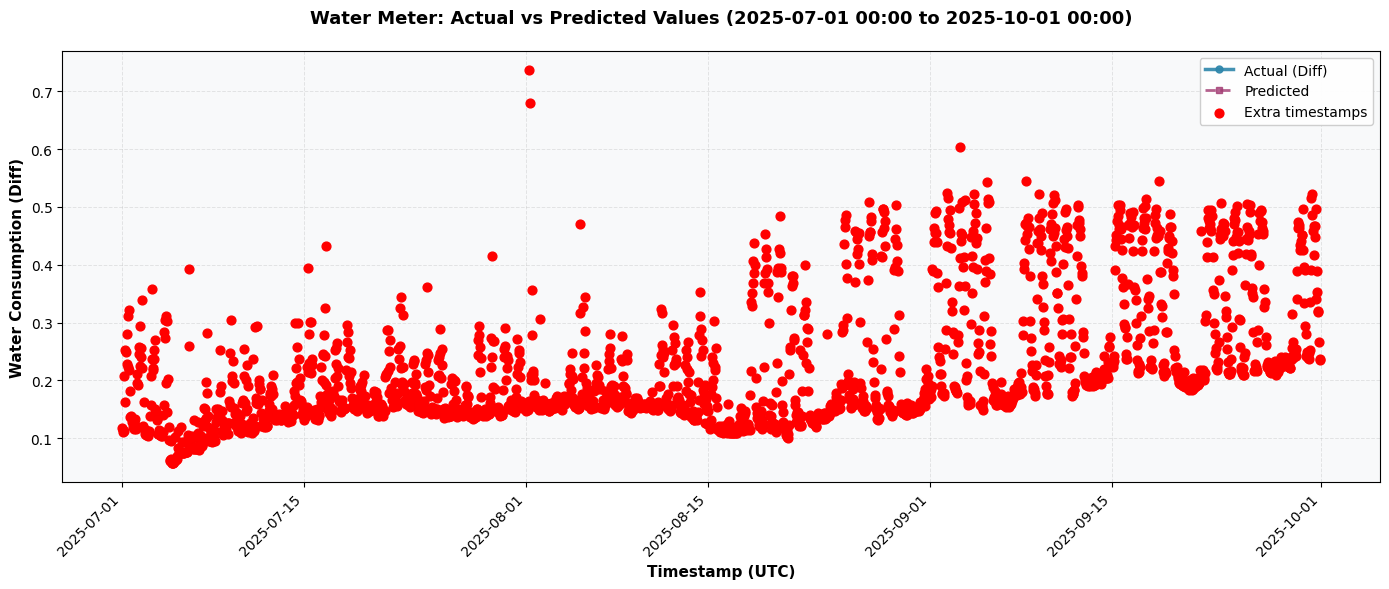

In [13]:
from local_level_unobserved_components import process_single_meter
process_single_meter(f'../data_w_diff_001/{meter_id}.csv', predictions_output_csv='../test_pred.csv')
df_predicted = pd.read_csv('../test_pred.csv')
df_predicted['timestamp_utc'] = pd.to_datetime(df_predicted['timestamp_utc'])

df_actuals_red_dot = pd.read_csv(f'../data_w_diff_001/{meter_id}.csv').dropna()
df_actuals_red_dot['timestamp_utc'] = pd.to_datetime(df_actuals_red_dot['timestamp_utc'])

df_actuals_with_gaps = df_predicted[['actual', 'timestamp_utc']].rename(columns={'actual': 'Diff'})

fig1, ax1 = plot_water_meter_anomalies(df_actuals=df_actuals_with_gaps, df_predicted=df_predicted, df_red_dots=df_actuals_red_dot,
    start_date='2025-07-01 00:00:00+00:00',
    end_date='2025-10-01 00:00:00+00:00')

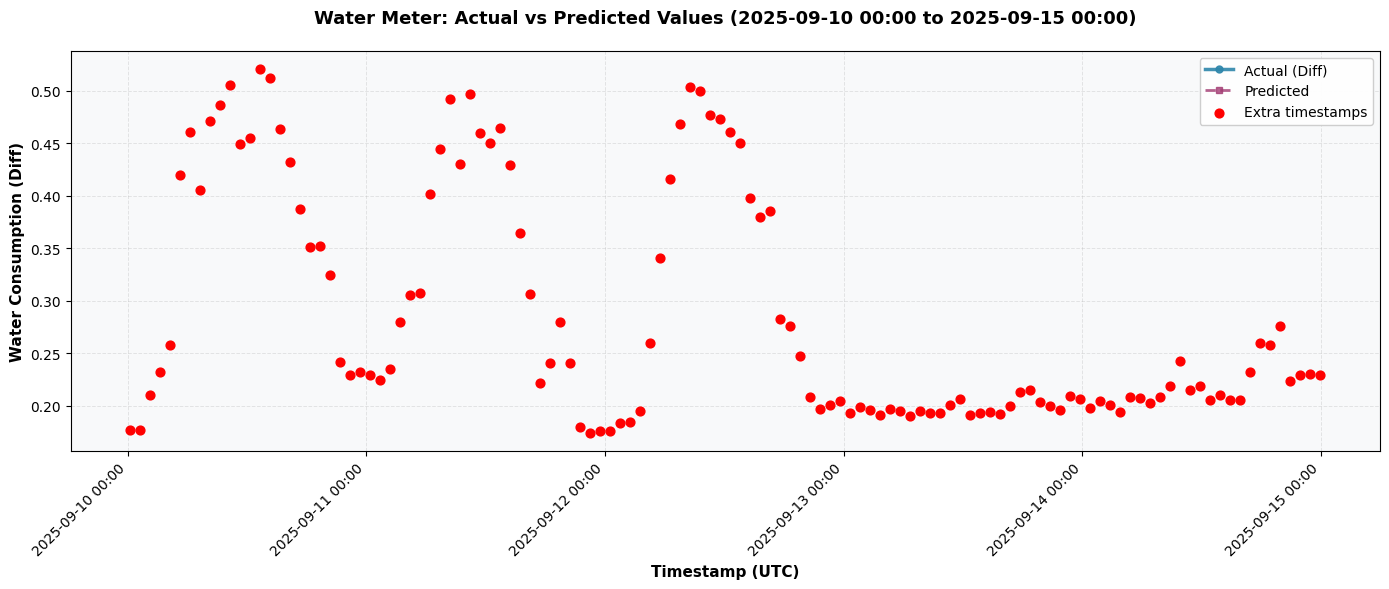

In [14]:
fig2, ax2 = plot_water_meter_anomalies(df_actuals=df_actuals_with_gaps, df_predicted=df_predicted, df_red_dots=df_actuals_red_dot,
        start_date=start_date,
        end_date=end_date)
plt.show()

In [15]:
def plot_two_histograms_with_stats(
    df1,
    df2,
    metric,
    bins='auto',
    density=False,
    x_range=None,
    title1='Seasonal',
    title2='Local'
):
    """
    Plot two histograms in one figure and display a combined stats box.
    Remaining params are shared.
    """
    
    if metric not in df1.columns or metric not in df2.columns:
        print("Incorrect metric name.")
        
    values1 = df1[metric]
    values2 = df2[metric]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    fig.suptitle(metric, fontsize=14)

    # Combined range
    min_val = min(np.min(values1), np.min(values2))
    max_val = max(np.max(values1), np.max(values2))

    if x_range is None:
        x_range = (min_val, max_val)

    def _add_hist_with_stats(ax, values, title):
        # Histogram
        ax.hist(values, bins=bins, density=density,
                range=x_range, color='skyblue', edgecolor='black')
        ax.set_title(title)
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')

        # Stats
        min_v = np.min(values)
        max_v = np.max(values)
        median_v = np.median(values.dropna())
        mean_v = np.mean(values)
        std_v = np.std(values)

        stats_lines = [
            f"Min: {min_v:.2f}",
            f"Max: {max_v:.2f}",
            f"Median: {median_v:.2f}",
            f"Mean: {mean_v:.2f}",
            f"Std: {std_v:.2f}",
        ]
        stats_text = "\n".join(stats_lines)

        font_size = max(8, min(10, 10 - len(stats_lines) // 2))

        ax.text(
            0.02, 0.98, stats_text,
            transform=ax.transAxes,
            va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontsize=font_size,
        )

    _add_hist_with_stats(ax1, values1, title1)
    _add_hist_with_stats(ax2, values2, title2)

    plt.tight_layout()
    plt.show()


In [16]:
summary_df_seasonal = pd.read_csv('./results_seasonal_uc_1000_seed_42_daily_clipped.csv')
summary_df_local = pd.read_csv('./results_local_trend_1000_seed_42_fixed_params_clipped.csv')

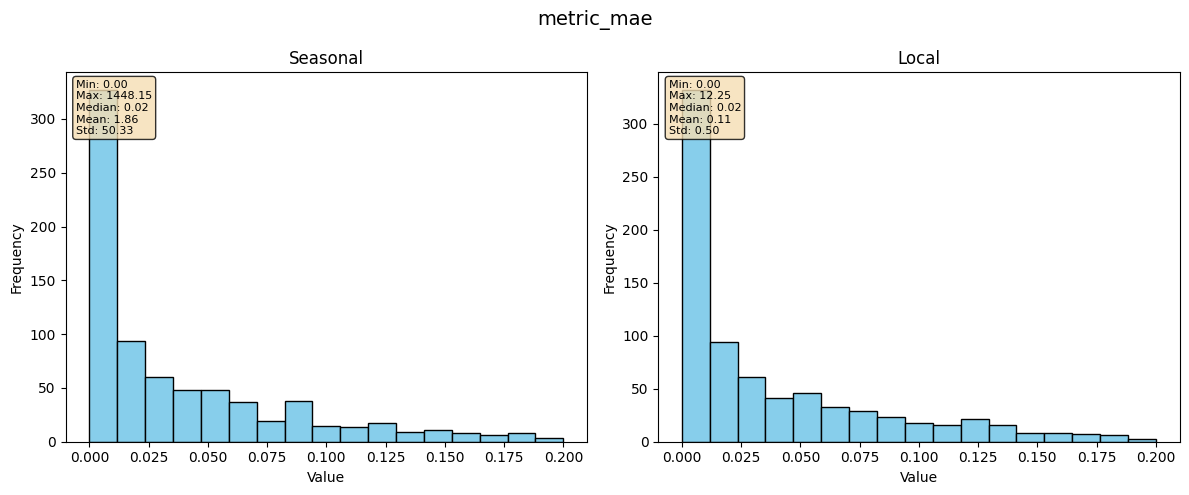

In [17]:
plot_two_histograms_with_stats(summary_df_seasonal, summary_df_local, 'metric_mae', x_range=(0, 0.2))

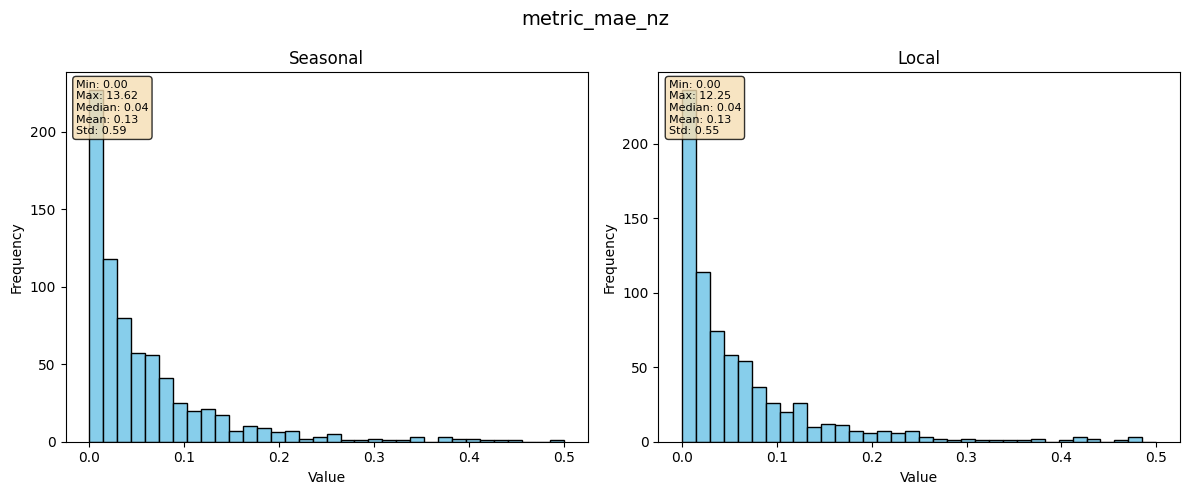

In [18]:
plot_two_histograms_with_stats(summary_df_seasonal, summary_df_local, 'metric_mae_nz', x_range=(0, 0.5))

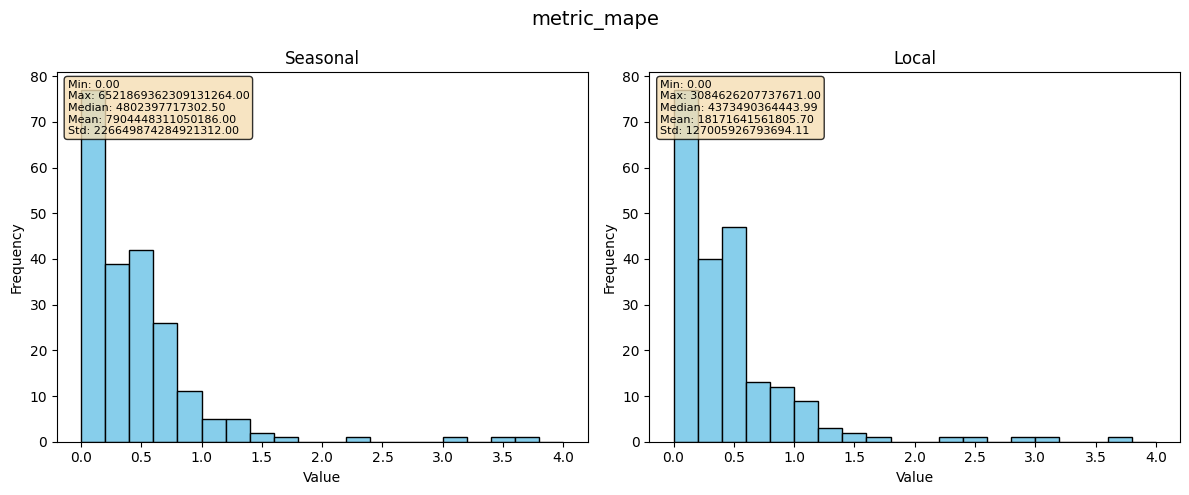

In [19]:
plot_two_histograms_with_stats(summary_df_seasonal, summary_df_local, 'metric_mape', bins=20, x_range=(0,4))

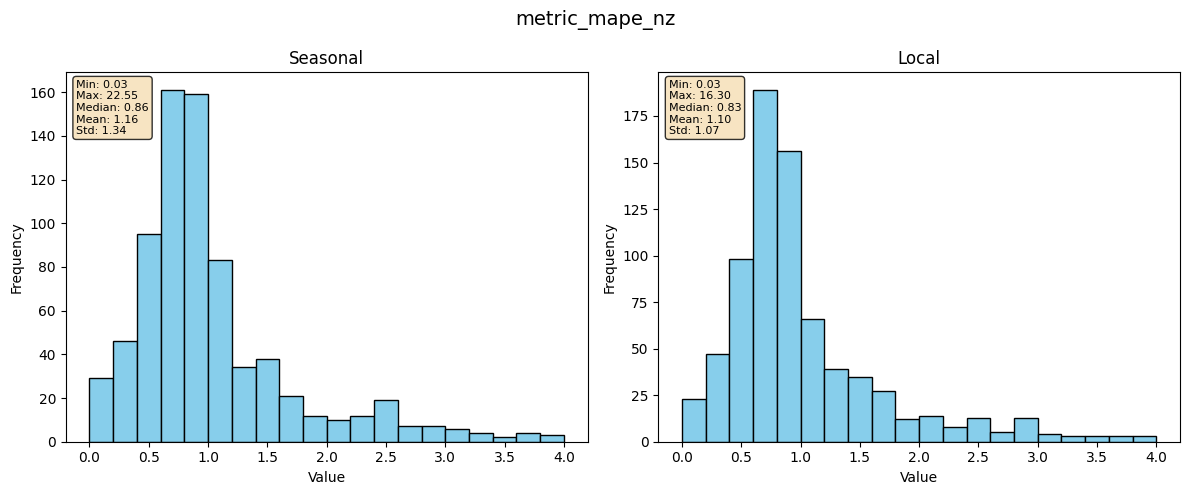

In [20]:
plot_two_histograms_with_stats(summary_df_seasonal, summary_df_local, 'metric_mape_nz', bins=20, x_range=(0,4))

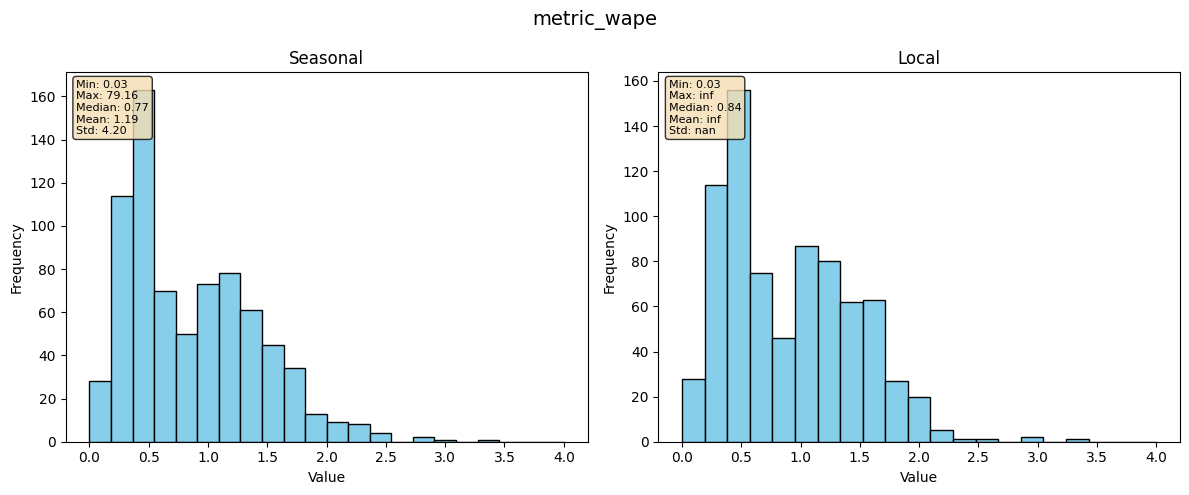

In [21]:
plot_two_histograms_with_stats(summary_df_seasonal, summary_df_local, 'metric_wape', x_range=(0,4))

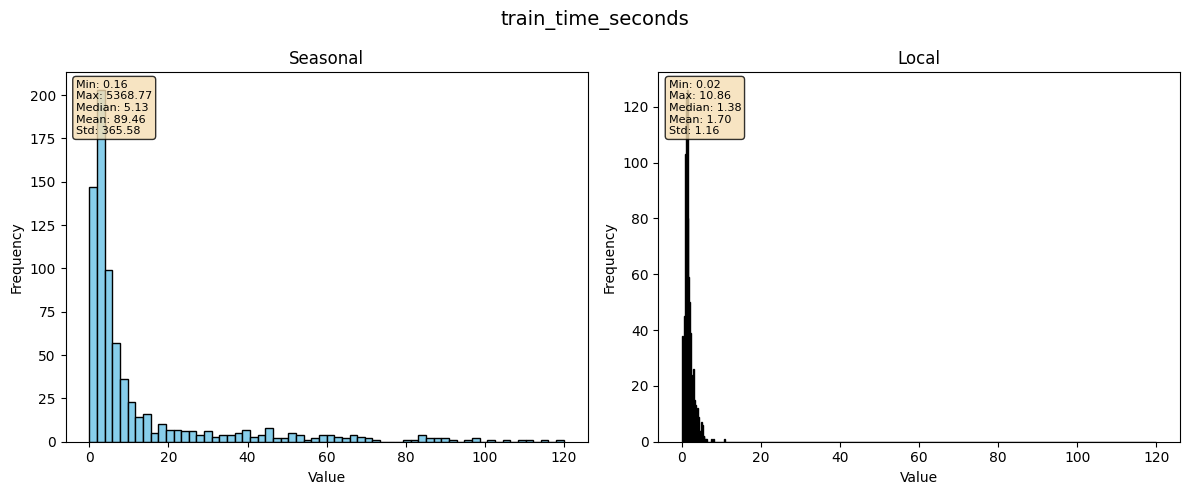

In [22]:
plot_two_histograms_with_stats(summary_df_seasonal, summary_df_local, 'train_time_seconds', x_range=(0,2*60))

In [23]:
df_candidates = get_candidates(summary_df_seasonal,
                       params=[
        #{"name": "converged_train", "value": False, "comparator": "=="},
        #{"name": "converged_second", "value": True, "comparator": "=="},
        #{"name": "status", "value": "success", "comparator": "=="},
        {"name": "train_time_seconds", "value": 5*60, "comparator": "<"},
        {"name": "second_train_time_seconds", "value": 5*60, "comparator": ">"},
        #{"name": "periodicity_seconds_train", "value": 1700, "comparator": "<="},
    ],)
display(df_candidates.head(5))
print(len(df_candidates))
display(df_candidates[['train_time_seconds', 'second_train_time_seconds']])

,filename,filepath,status,error,train_samples,second_train_samples,predict_samples,train_samples_filled,second_train_samples_filled,predict_samples_filled,periodicity_seconds_train,periodicity_seconds_second,periodicity_seconds_predict,seasonal_period_steps,converged_train,warnflag_train,gopt_train,train_time_seconds,train_loglike,converged_second,warnflag_second,gopt_second,second_train_time_seconds,second_train_loglike,prediction_time_seconds,metric_total_count,metric_valid_count,metric_nan_count,metric_valid_percentage,metric_rmse,metric_mae,metric_r2,metric_medae,metric_mape,metric_wape,metric_mean_residual,metric_std_residual,metric_max_residual,metric_min_residual,metric_p75_ae,metric_p90_ae,metric_normalized_rmse,metric_median_ape,metric_prediction_bias,metric_mpe,metric_direction_accuracy,metric_non_zero_count,metric_zero_count,metric_non_zero_percentage,metric_rmse_nz,metric_mae_nz,metric_medae_nz,metric_r2_nz,metric_mape_nz,metric_wape_nz,metric_mean_residual_nz,metric_std_residual_nz,metric_max_residual_nz,metric_min_residual_nz,metric_p75_ae_nz,metric_p90_ae_nz,metric_normalized_rmse_nz,metric_median_ape_nz,metric_prediction_bias_nz,metric_mpe_nz,metric_direction_accuracy_nz,anomalies_detected
103,80554,../data_w_diff_001\80554.csv,success,NaN,654.0,636.0,604.0,743.0,719.0,740.0,3596.0,3598.0,3598.0,24.0,False,2.0,[ 11649.00135443 18987.63310374 313029.20811902],105.814551,4984.607105,False,2.0,[531983.67167538 12557.6884035 15872.62822298],434.584565,4702.176544,348.196492,740.0,523.0,217.0,70.675676,0.000000,0.000000,1.000000,0.000000,0.000000e+00,NaN,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,1.000000,0.0,523.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
105,61494,../data_w_diff_001\61494.csv,success,NaN,2172.0,2222.0,2142.0,2231.0,2231.0,2159.0,1200.0,1200.0,1200.0,72.0,False,2.0,[ 104.39981094 1783.2308529 230.41174162],63.470582,9475.087005,False,2.0,[10040.07589801 6326.46599841 26956.8847284 ],1225.216370,19176.611302,1.528182,2159.0,2128.0,31.0,98.564150,0.000000,0.000000,1.000000,0.000000,0.000000e+00,NaN,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,1.000000,0.0,2128.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
160,145687,../data_w_diff_001\145687.csv,success,NaN,2826.0,2767.0,2737.0,2975.0,2975.0,2879.0,890.0,878.0,892.0,97.0,True,NaN,NaN,111.779701,11431.027133,False,2.0,[ 2.21401417 5.61203074 -0.53210691],326.098210,10887.445551,63.902954,2879.0,2596.0,283.0,90.170198,0.004734,0.002227,0.014024,0.001101,4.902222e+12,1.625393,0.002227,0.004177,0.053837,0.0,0.002421,0.004593,0.992963,71259.333509,-0.000002,-108851.119580,0.611561,347.0,2249.0,13.366718,0.012058,0.008518,0.005423,-0.840801,0.823487,0.830966,0.008518,0.008534,0.053837,0.000010,0.011011,0.020317,1.356761,0.851256,-0.008162,0.540457,0.508671,9.0
205,143722,../data_w_diff_001\143722.csv,success,NaN,663.0,635.0,607.0,743.0,742.0,719.0,3590.0,3581.0,3600.0,24.0,True,NaN,NaN,133.774318,823.409632,True,NaN,NaN,483.188161,543.946941,166.467992,719.0,519.0,200.0,72.183588,0.037408,0.022269,0.055010,0.012544,2.911508e+13,0.963121,0.022269,0.030058,0.218276,0.0,0.027576,0.052104,0.972106,0.855659,0.000505,-646484.767480,0.608108,275.0,244.0,52.986513,0.046988,0.029826,0.018000,-0.162318,0.939210,0.683517,0.029826,0.036307,0.218276,0.000188,0.035267,0.069938,1.078108,0.593216,-0.011247,-0.281876,0.602190,0.0
395,147352,../data_w_diff_001\147352.csv,success,NaN,733.0,731.0,709.0,744.0,742.0,719.0,3569.0,3600.0,3584.0,24.0,True,NaN,NaN,247.691297,654.514580,True,NaN,NaN,314.900241,621.779284,46.242079,719.0,696.0,23.0,96.801113,0.123048,0.085617,0.653705,0.060110,4.893801e+12,0.315189,0.085617,0.088376,0.790585,0.0,0.119561,0.200252,0.588468,0.309460,-0.003541,-108664.482552,0.648921,675.0,21.0,96.982759,0.124610,0.087160,0.061270,0.636484,0.616263,0.311188,0.087160,0.089055,0.790585,0.000197,0.122234,0.2009

13


,train_time_seconds,second_train_time_seconds
103,105.814551,434.584565
105,63.470582,1225.216370
160,111.779701,326.098210
205,133.774318,483.188161
395,247.691297,314.900241
500,193.078530,528.396598
539,61.809717,446.343500
621,8.037535,580.140537
652,197.585971,773.153454
772,209.035706,342.667241


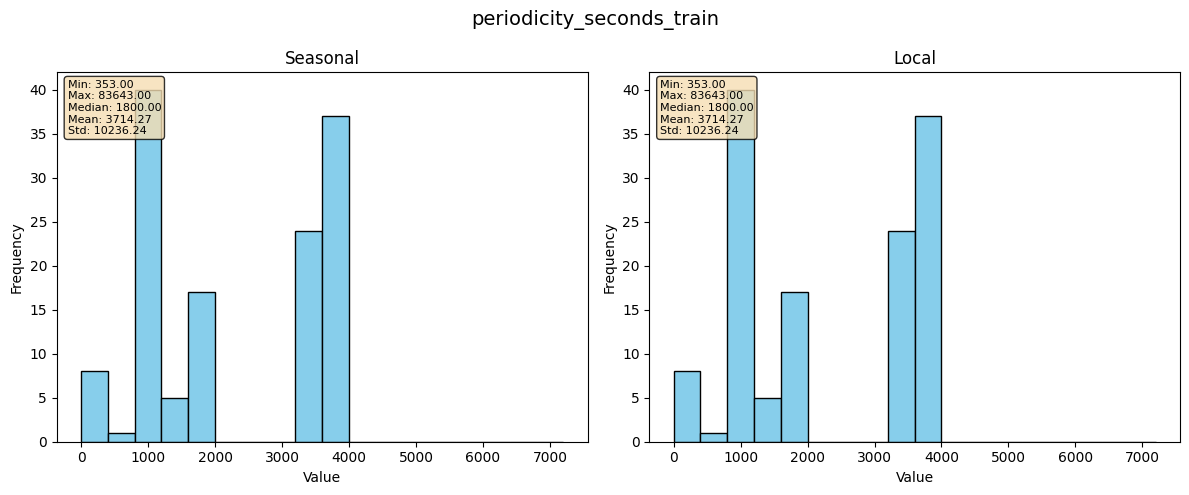

In [24]:
df_candidates = get_candidates(summary_df_seasonal,
                       params=[
        #{"name": "converged_train", "value": False, "comparator": "=="},
        #{"name": "converged_second", "value": True, "comparator": "=="},
        #{"name": "status", "value": "success", "comparator": "=="},
        {"name": "train_time_seconds", "value": 60, "comparator": ">"},
        #{"name": "periodicity_seconds_train", "value": 1200, "comparator": "<="},
    ],)

plot_two_histograms_with_stats(df_candidates, df_candidates, 'periodicity_seconds_train', x_range=(0, 60*120))

In [25]:
def plot_df_scatter(df, x_col, y_col, x_lim = None, y_lim = None):
    """
    Simple scatter: x = one df column, y = another df column.
    """
    plt.figure(figsize=(6, 5))
    plt.scatter(df[x_col], df[y_col], color='steelblue', alpha=0.7, edgecolors='black')  # points in the middle[web:44][web:53]
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'{x_col} vs {y_col}')
    plt.grid(True, linestyle=':', alpha=0.4)
    
    if x_lim is not None:
        plt.xlim(x_lim)  # expects (xmin, xmax)[web:62][web:68]
    if y_lim is not None:
        plt.ylim(y_lim)  # expects (ymin, ymax)[web:64][web:61]
    
    plt.tight_layout()
    plt.show()


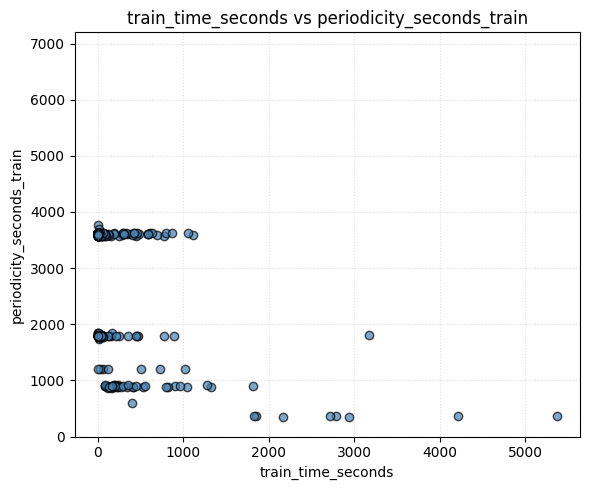

In [26]:
plot_df_scatter(summary_df_seasonal, 'train_time_seconds', 'periodicity_seconds_train', y_lim = (0, 120*60))

Decision tree was trained and fitted to not waste time on potential longer meters. 

Also a timout was added and also meters with too short periodicity are trained and compared on 2week blocks and not 1 months blocks

Also train, second and test data has to have much closer periodicity (number of steps per period must be the same).

The lenght of the whole period can differ by maximum 33% of the periodicity

Also at least 100 days of data is needed to test the meter

## Compare Unobserved Components weekly periodicity

One model with Fourier with 2 harmonics for weekly periodicity
And default one without periodicity

In [40]:
# 2. Compute summary statistics
csv_filepaths = [
                './results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_600_reworked.csv', 
                './results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_600_reworked_weekly_fourier_2.csv', 
                './results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_600_reworked_weekly_fourier_2_daily_fourier_2_no_seasonal.csv'
                ]

model_names = [
                "Daily steps only (default)",
                "Daily steps + weekly freq Fourier",
                "Daily + weekly Fourier",
]
summary_converged_only = compute_metrics_summary(csv_filepaths, only_converged=True, model_names=model_names)
table = display_metrics(summary_converged_only, show_all=True)
display(table)  # Use IPython display in Jupyter

Loading 3 model(s)...
--------------------------------------------------------------------------------
✓ Loaded 731 successful runs
  Daily steps only (default): filtered to 531 converged_train runs
✓ Loaded 731 successful runs
  Daily steps + weekly freq Fourier: filtered to 512 converged_train runs
✓ Loaded 731 successful runs
  Daily + weekly Fourier: filtered to 446 converged_train runs
--------------------------------------------------------------------------------
Metrics Summary - All Metrics
Models: Daily steps only (default), Daily steps + weekly freq Fourier, Daily + weekly Fourier
  Daily steps only (default): 531 successful runs
  Daily steps + weekly freq Fourier: 512 successful runs
  Daily + weekly Fourier: 446 successful runs



,Metric,Daily steps only (default),Daily steps + weekly freq Fourier,Daily + weekly Fourier
0,metric_direction_accuracy,0.5744 ± 0.0922,0.5718 ± 0.0864,0.5651 ± 0.0820
1,metric_direction_accuracy_nz,0.5423 ± 0.0955,0.5387 ± 0.0857,0.5386 ± 0.0886
2,metric_mae,8.8093 ± 200.4668,0.4189 ± 6.6666,0.4924 ± 7.9823
3,metric_mae_nz,35.8159 ± 819.2992,1.1850 ± 23.3833,1.4717 ± 28.0220
4,metric_mape,25456514117647580.0000 ± 585455050131975808.0000,35217665626580.0938 ± 254512474636411.0312,45527817240146.4062 ± 262304653659777.8125
5,metric_mape_nz,790.4812 ± 18116.2237,7.6167 ± 122.6056,9.0559 ± 159.8396
6,metric_max_residual,1884.1863 ± 43396.2620,98.3326 ± 2148.1767,111.2339 ± 2301.2395
7,metric_max_residual_nz,1898.4829 ± 43560.6423,98.8925 ± 2154.4979,111.7038 ± 2309.0239
8,metric_mean_residual,8.8093 ± 200.4668,0.4189 ± 6.6666,0.4924 ± 7.9823
9,metric_mean_residual_nz,35.8159 ± 819.2992,1.1850 ± 23.3833,1.4717 ± 28.0220


In [41]:
df_metrics_seasonal = pd.read_csv('./results_seasonal_uc_10_seed_42_daily_clipped_tree_timeout_600_reworked.csv')
df_metrics_weekly = pd.read_csv('./results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_600_reworked_weekly_fourier_2.csv')

filename = pick_random_file(
    df_metrics_seasonal,
    df_metrics_weekly,
    params=[
        {"name": "converged_train", "value": True, "comparator": "=="},
        {"name": "converged_second", "value": True, "comparator": "=="},
        {"name": "status", "value": "success", "comparator": "=="},
        #{"name": "metric_mape_nz", "value": 0.1, "comparator": ">"},
    ],
    seed=42,
)

meter_id = 144433
#137402 - normal one, big acf1 on non seasonal
#90986 - convergede but spikes
#131493 - big acf1 even seasonal
#106555 - stoupajici diff
#58425 - unconverged train but second yes - long seasonal train time, 10min period, small gopt
#108627 - converged local, unconverged seasonal, not enough data
#144433 - same as above just enogh data but random spikes
#141674 - both unconverged - flat
#131721 - both unconverged - not flat, small gopt

,seasonal,local_linear
filename,103458,103458
filepath,../data_w_diff_001\103458.csv,../data_w_diff_001\103458.csv
status,success,success
error,NaN,NaN
train_predict_window_days,30.0,30.0
train_samples,650.0,650.0
second_train_samples,643.0,643.0
predict_samples,616.0,616.0
train_samples_filled,718.0,718.0
second_train_samples_filled,720.0,720.0


2026-03-05 12:20:34,419 - local_level_unobserved_components - ERROR - Failed: 144433 - Error: All three periodicities are not within 33.300000000000004% range. Since if we apply daily steps the last steps of two seasons differ by more then 290.709 seconds. Periodicity Train: 873.0, Periodicity Second: 900.0, Periodicity Predict: 924.0.


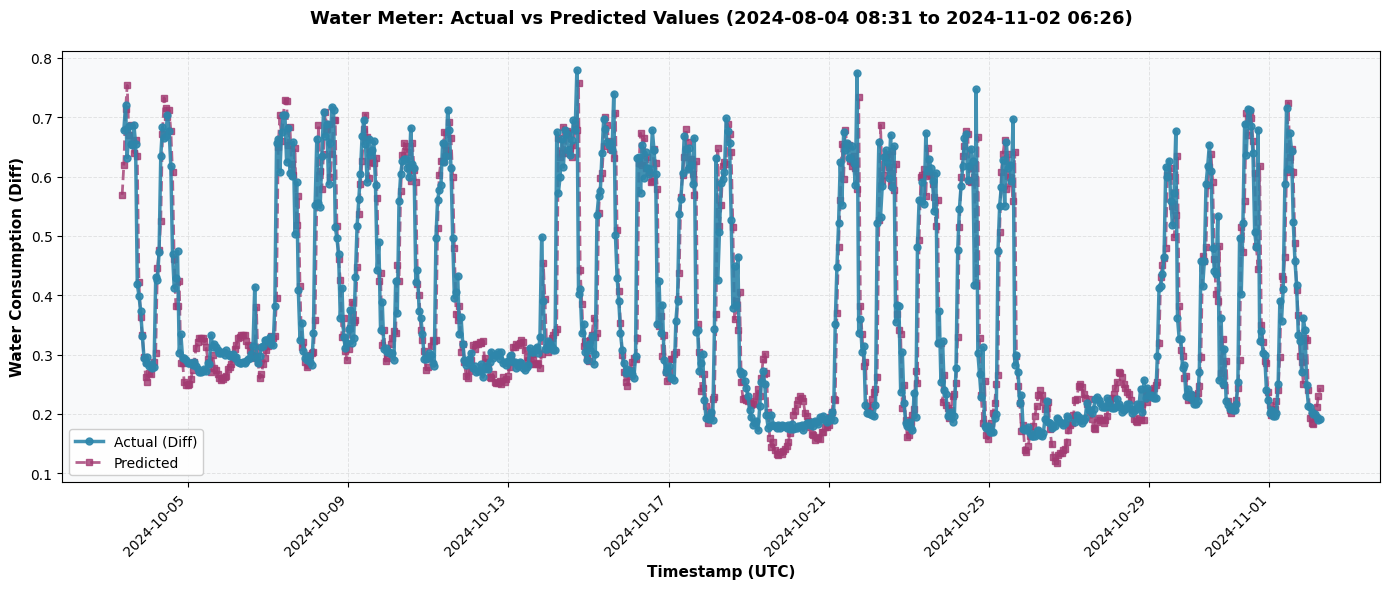

In [42]:
from local_level_unobserved_components import process_single_meter
process_single_meter(f'../data_w_diff_001/{meter_id}.csv', predictions_output_csv='../test_pred.csv', weekly_seasonality=True)
df_predicted = pd.read_csv('../test_pred.csv')
df_predicted['timestamp_utc'] = pd.to_datetime(df_predicted['timestamp_utc'])

df_actuals_red_dot = pd.read_csv(f'../data_w_diff_001/{meter_id}.csv').dropna()
df_actuals_red_dot['timestamp_utc'] = pd.to_datetime(df_actuals_red_dot['timestamp_utc'])

df_actuals_with_gaps = df_predicted[['actual', 'timestamp_utc']].rename(columns={'actual': 'Diff'})

fig1, ax1 = plot_water_meter_anomalies(df_actuals=df_actuals_with_gaps, df_predicted=df_predicted, df_red_dots=df_actuals_red_dot,
    start_date=df_actuals_with_gaps['timestamp_utc'].iloc[0] - pd.Timedelta(days=60),
    end_date=df_actuals_with_gaps['timestamp_utc'].iloc[-1])

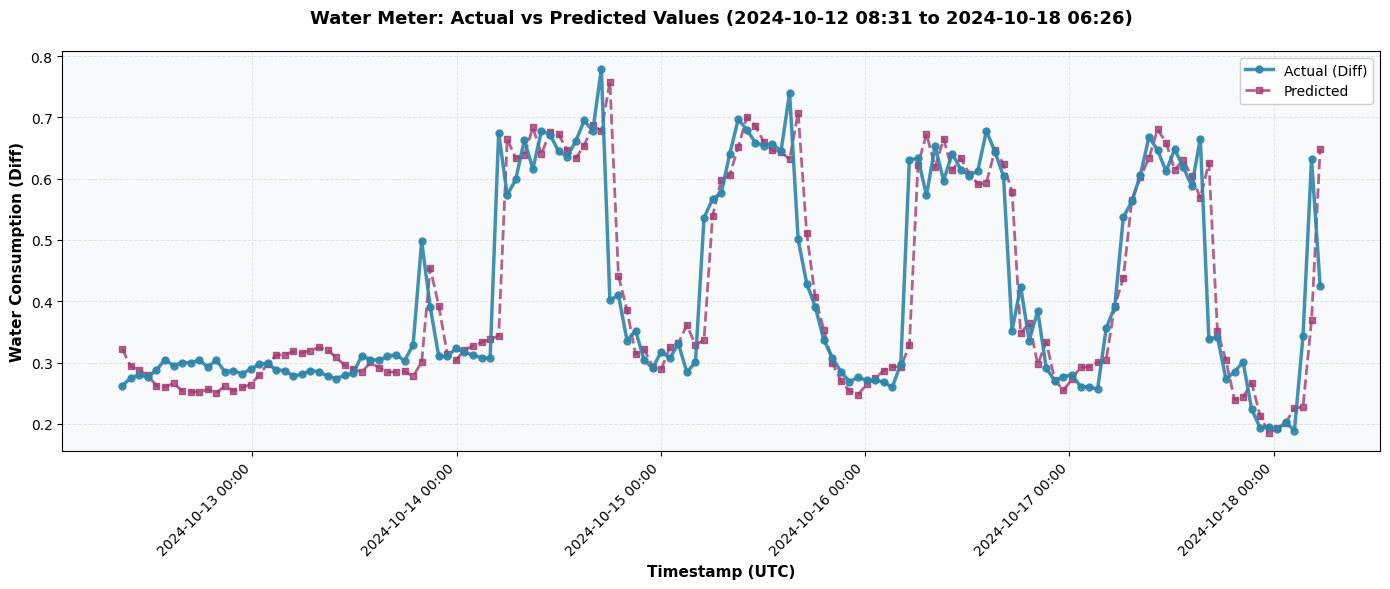

In [43]:
fig2, ax2 = plot_water_meter_anomalies(df_actuals=df_actuals_with_gaps, df_predicted=df_predicted, df_red_dots=df_actuals_red_dot, 
        start_date=df_actuals_with_gaps['timestamp_utc'].iloc[0] + pd.Timedelta(days=9),
        end_date=df_actuals_with_gaps['timestamp_utc'].iloc[-1] - pd.Timedelta(days=15))
plt.show()

2026-03-05 12:20:42,589 - local_level_unobserved_components - ERROR - Failed: 144433 - Error: All three periodicities are not within 33.300000000000004% range. Since if we apply daily steps the last steps of two seasons differ by more then 290.709 seconds. Periodicity Train: 873.0, Periodicity Second: 900.0, Periodicity Predict: 924.0.


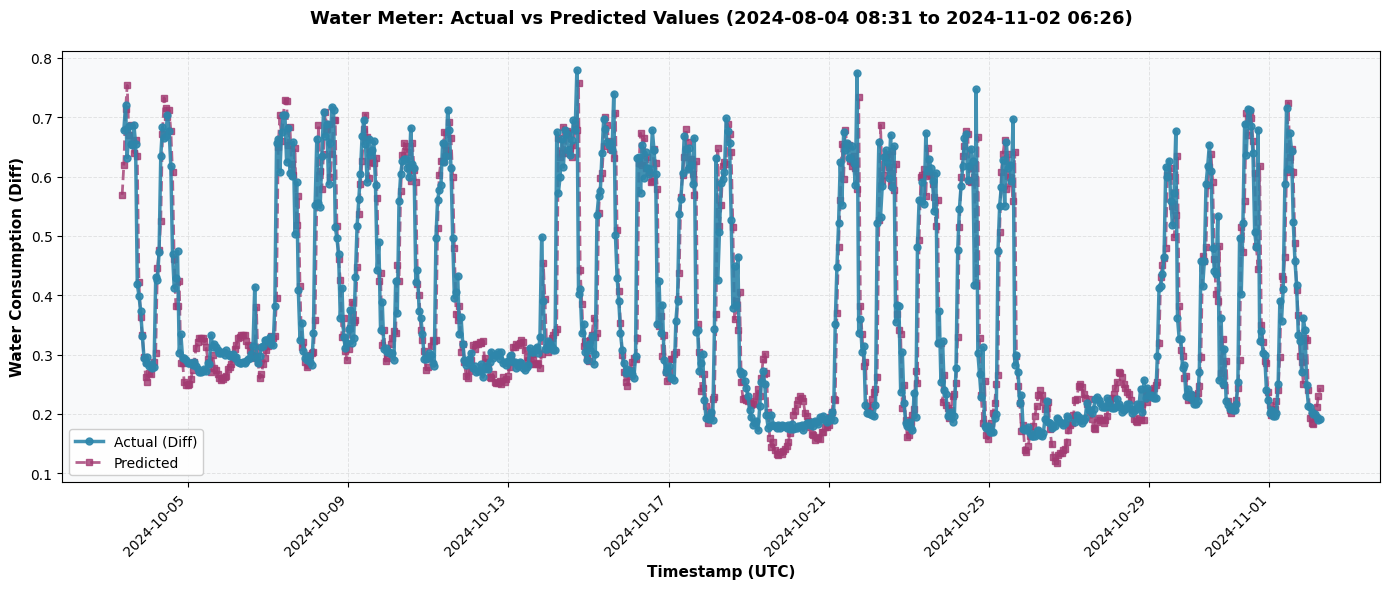

In [44]:
from local_level_unobserved_components import process_single_meter
process_single_meter(f'../data_w_diff_001/{meter_id}.csv', predictions_output_csv='../test_pred.csv', weekly_seasonality=False)
df_predicted = pd.read_csv('../test_pred.csv')
df_predicted['timestamp_utc'] = pd.to_datetime(df_predicted['timestamp_utc'])

df_actuals_red_dot = pd.read_csv(f'../data_w_diff_001/{meter_id}.csv').dropna()
df_actuals_red_dot['timestamp_utc'] = pd.to_datetime(df_actuals_red_dot['timestamp_utc'])

df_actuals_with_gaps = df_predicted[['actual', 'timestamp_utc']].rename(columns={'actual': 'Diff'})

fig1, ax1 = plot_water_meter_anomalies(df_actuals=df_actuals_with_gaps, df_predicted=df_predicted, df_red_dots=df_actuals_red_dot,
    start_date=df_actuals_with_gaps['timestamp_utc'].iloc[0] - pd.Timedelta(days=60),
    end_date=df_actuals_with_gaps['timestamp_utc'].iloc[-1])

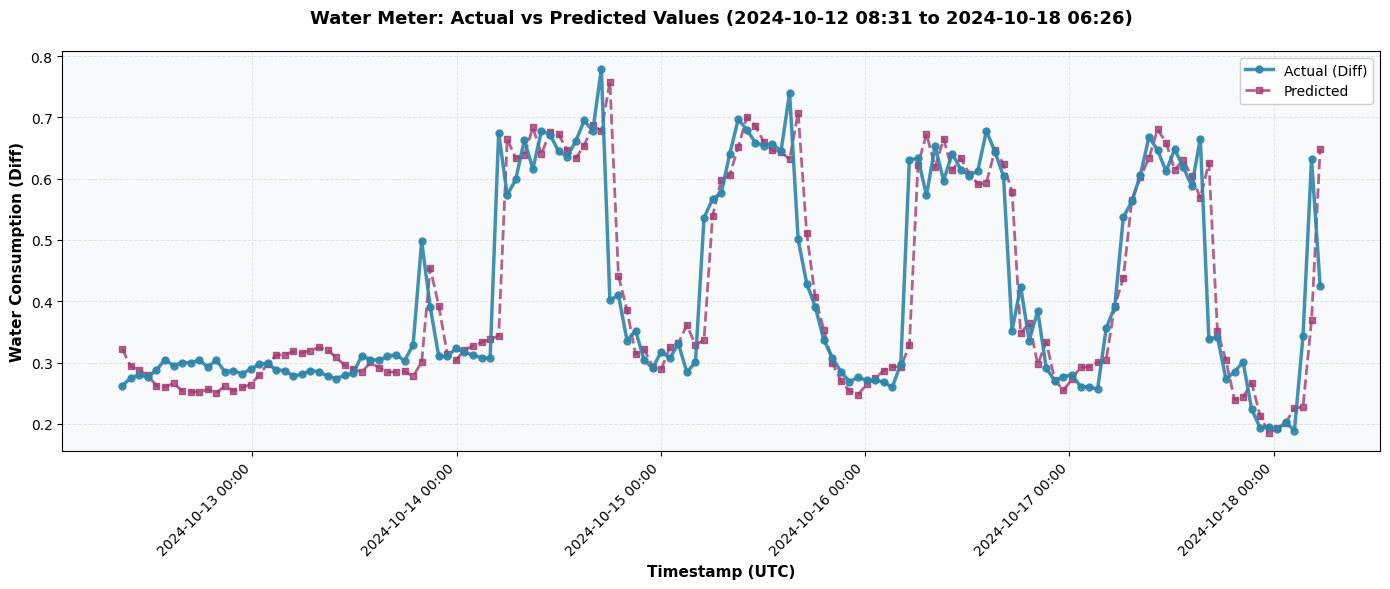

In [45]:
fig2, ax2 = plot_water_meter_anomalies(df_actuals=df_actuals_with_gaps, df_predicted=df_predicted, df_red_dots=df_actuals_red_dot, 
        start_date=df_actuals_with_gaps['timestamp_utc'].iloc[0] + pd.Timedelta(days=9),
        end_date=df_actuals_with_gaps['timestamp_utc'].iloc[-1] - pd.Timedelta(days=15))
plt.show()